# Sistema y simulación

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from numba import njit

@njit
def time_series(x_0, steps, dt, params):
    tau = params[0]
    K = params[1]
    sigma = params[2]
    x = np.zeros(steps)
    x[0] = x_0[0]
    epsilon = np.random.standard_normal(steps)

    for i in range(1, steps):
        dx_dt = x[i-1] * (1 + sigma * epsilon[i-1] - x[i-1] / K) / tau
        x[i] = x[i-1] + dx_dt * dt

    return x

@njit
def samples(x_0, steps, dt, params):
    tau = params[0]
    K = params[1]
    sigma = params[2]
    N = np.shape(x_0)[0]
    x = np.zeros(N)
    x = x_0

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)

        dx_dt = x * (1 + sigma * epsilon - x / K) / tau
        x = x + dx_dt * dt

    return x

## Primera ley

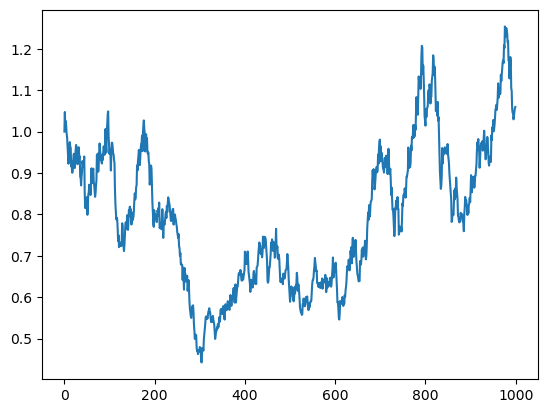

mu:  0.7963047354813596
std:  0.17359231875071898


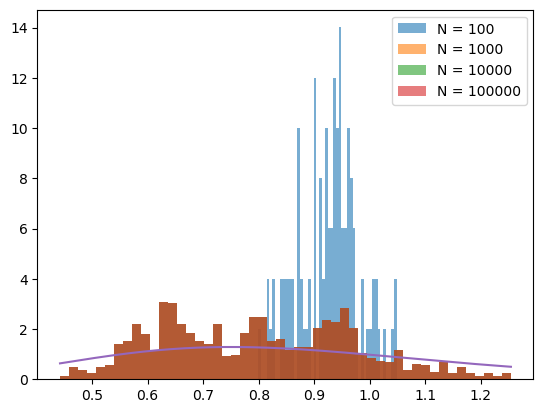

In [3]:
N = 100000
x_0 = np.ones(N)
steps = 1000
dt = 0.01
tau = 4
K = 1
sigma = 1
params = (tau, K, sigma/np.sqrt(dt))
alpha = 2 * tau / sigma**2 - 1
beta = 2 * tau / (K * sigma**2)

x = time_series(x_0, steps, dt, params)
plt.plot(x)
plt.show()

mu = x.mean()
std = x.std()
print("mu: ", mu)
print("std: ", std)

plt.hist(x[:N//1000], bins=50, density=True, alpha=0.6, label=f"N = {N//1000}")
plt.hist(x[:N//100], bins=50, density=True, alpha=0.6, label=f"N = {N//100}")
plt.hist(x[:N//10], bins=50, density=True, alpha=0.6, label=f"N = {N//10}")
_, bins, _ = plt.hist(x, bins=50, density=True, alpha=0.6, label=f"N = {N}")

x_range = np.linspace(bins.min(), bins.max(), 1000)

gamma = beta**alpha / sc.special.gamma(alpha) * x_range ** (alpha-1) * np.exp(-x_range * beta)
plt.plot(x_range, gamma)
plt.legend()

plt.show()

## Segunda ley

In [ ]:
tau_range = 1 / np.linspace(2, 0.1, 100)
K_range = np.linspace(1, 1000, 100)
sigma_range = np.sqrt(np.linspace(0, 3, 100))

N = 1000
x_0 = np.ones(N)
steps = 1000
dt = 0.01
tau = 4
K = 1
sigma = 1

# Variando tau
mean = np.zeros(len(tau_range))
var = np.zeros(len(tau_range))

for i in range(len(tau_range)):
    params = (tau_range[i], K, sigma/np.sqrt(dt))
    rectified_steps = steps*2*tau_range[i]
    x = samples(x_0, rectified_steps, dt, params)
    mean[i] = x.mean()
    var[i] = x.var()
    print("Ejecutado paso ", i)

plt.plot(mean**2, var, 'b.')
plt.xlabel(r"Mean$^2$")
plt.ylabel("Variance")


steps: 1000.0
Ejecutado paso  0
steps: 1009.6889342172361
Ejecutado paso  1
steps: 1029.445978244144
Ejecutado paso  2
steps: 1059.9599775992747
Ejecutado paso  3
steps: 1102.2693044362206
Ejecutado paso  4
steps: 1157.8213383467996
Ejecutado paso  5
steps: 1228.5564040335817
Ejecutado paso  6
steps: 1317.023107734971
Ejecutado paso  7
steps: 1426.5348759930214
Ejecutado paso  8
steps: 1561.3814563107699
Ejecutado paso  9
steps: 1727.1146835169407
Ejecutado paso  10
steps: 1930.9356710127286
Ejecutado paso  11
steps: 2182.221819980138
Ejecutado paso  12
steps: 2493.2482421007926
Ejecutado paso  13
steps: 2880.1817499180684
Ejecutado paso  14
steps: 3364.460097249425
Ejecutado paso  15
steps: 3974.7201626216356
Ejecutado paso  16
steps: 4749.51473867884
Ejecutado paso  17
steps: 5741.171662139257
Ejecutado paso  18
steps: 7021.321736279018
Ejecutado paso  19
steps: 8688.885648645286
Ejecutado paso  20
steps: 10881.716372117437
Ejecutado paso  21
steps: 13793.72497874041
Ejecutado paso  